In [5]:
import pandas as pd
import wandb
from tqdm import tqdm

api = wandb.Api(timeout=50)

runs = api.runs("lab_frohlich/DeepMechanisticModels.v58_fig1b.dream_cytof")

all_rows = []
for run in tqdm(runs):
    context = run.config.get("context")
    samples = run.config.get("samples")
    n_hidden = run.config.get("n_hidden")
    depth = run.config.get("depth")
    features = run.config.get("features")
    features_selection = run.config.get("features_selection")
    job = run.config.get("job")
    l1reg_inflater_output = run.config.get("l1reg_inflater_output")
    inflater_output_reg_epoch = run.config.get("inflater_output_reg_epoch")
    l2reg_inflater_output = run.config.get("l2reg_inflater_output")
    sparse_threshold_perc = run.config.get("sparse_threshold_perc")

    if (l1reg_inflater_output != 0.01) | (l2reg_inflater_output != 0) | (n_hidden != 2) | (depth != 0):
        continue

    try:
        history = run.scan_history(
            keys=["rmse_train", "rmse_val", "_step", "log_parameter_std"]
        )
    except Exception as e:
        print(f"Skipping run {run.id} due to error: {e}")
        continue

    for row in history:
        if row.get("rmse_train") is not None and row.get("rmse_val") is not None:
            all_rows.append({
                # Config
                "context": context,
                "samples": samples,
                "n_hidden": n_hidden,
                "depth": depth,
                "features": features,
                "features_selection": features_selection,
                "job": job,
                "l1reg_inflater_output": l1reg_inflater_output,
                "inflater_output_reg_epoch": inflater_output_reg_epoch,
                "l2reg_inflater_output": l2reg_inflater_output,
                "sparse_threshold_perc": sparse_threshold_perc,
                # Epoch
                "step": row["_step"],
                # RMSEs
                "rmse_train": row["rmse_train"],
                "rmse_val": row["rmse_val"],
            })

results_df = pd.DataFrame(all_rows)

100%|██████████| 3800/3800 [03:07<00:00, 20.32it/s]


In [9]:
results_df[results_df.step == results_df.step.max()].groupby(["context", "features"]).rmse_val.mean()

context          features           
cytof_init       RFE_10_permute         0.527513
multimodal       RFE_10_permute         0.595797
                 best_RFE_10_permute    0.474776
proteomics       HVGRFE_10_permute      0.897693
transcriptomics  HVGRFE_10_permute      0.842979
Name: rmse_val, dtype: float64

In [11]:
results_df[results_df.step == results_df.step.max()].groupby(["context", "features", "samples"]).rmse_val.mean()

context          features             samples 
cytof_init       RFE_10_permute       BT20        0.570635
                                      EVSAT       0.457713
                                      HCC1500     0.518841
                                      MCF7        0.539789
                                      UACC3199    0.550585
multimodal       RFE_10_permute       BT20        0.534519
                                      EVSAT       0.795805
                                      HCC1500     0.421353
                                      MCF7        0.699260
                                      UACC3199    0.528049
                 best_RFE_10_permute  BT20        0.536153
                                      EVSAT       0.429149
                                      HCC1500     0.471237
                                      MCF7        0.411384
                                      UACC3199    0.525955
proteomics       HVGRFE_10_permute    BT20        0.622502
         

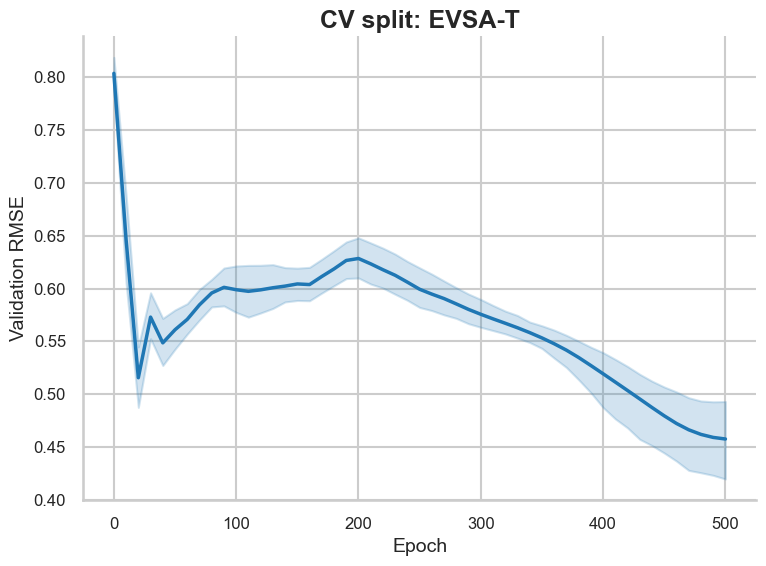

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set modern style
sns.set_theme(style="whitegrid", context="talk")

# Filtered data
subset = results_df[
    (results_df.context == "cytof_init")
    & (results_df.n_hidden == 2) & (results_df.depth == 0)
    & (results_df.l1reg_inflater_output == 1e-2) & (results_df.l2reg_inflater_output == 0)
    & (results_df.samples == "EVSAT")
]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(
    data=subset,
    x="step",
    y="rmse_val",
    linewidth=2.5,
    color="tab:blue",
    ax=ax
)

# Formatting
ax.set_title("CV split: EVSA-T", fontsize=18, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=14)
ax.set_ylabel("Validation RMSE", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=12)

sns.despine()
plt.tight_layout()
plt.show()

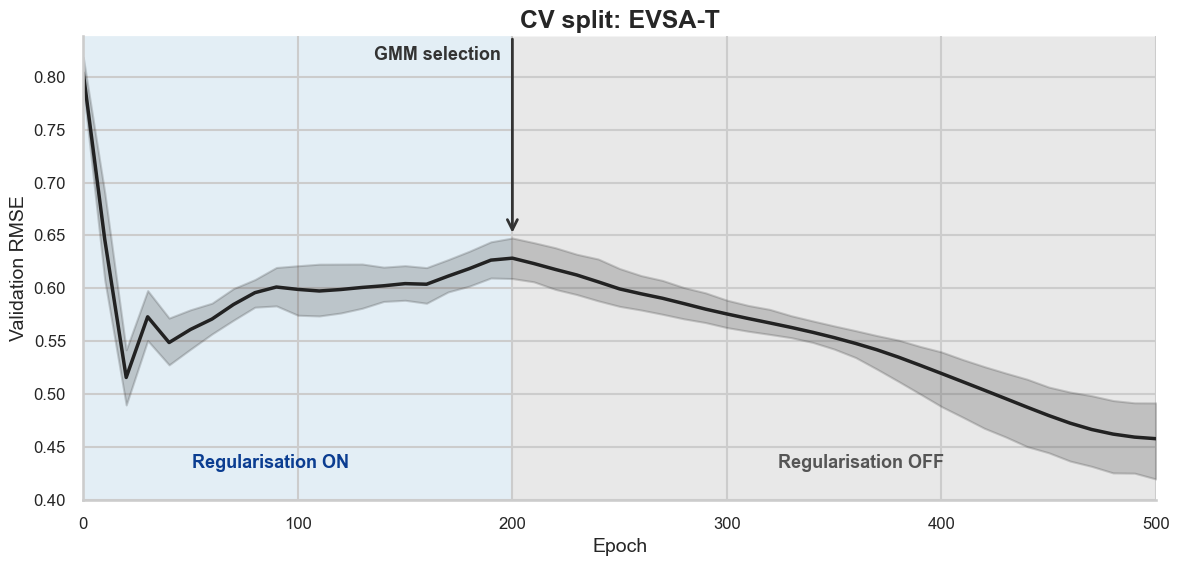

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Style
sns.set_theme(style="whitegrid", context="talk")

# Filtered data
subset = results_df[
    (results_df.context == "cytof_init")
    & (results_df.n_hidden == 2) & (results_df.depth == 0)
    & (results_df.l1reg_inflater_output == 1e-2) & (results_df.l2reg_inflater_output == 0)
    & (results_df.samples == "EVSAT")
]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot training curve in dark gray (almost black)
sns.lineplot(
    data=subset,
    x="step",
    y="rmse_val",
    linewidth=2.5,
    color="#222222",   # near-black
    ax=ax
)

ax.set_title("CV split: EVSA-T", fontsize=18, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=14)
ax.set_ylabel("Validation RMSE", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=12)

# Get axis limits to position arrow/text cleanly
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min

epoch_cut = 200

# Shaded regions
ax.axvspan(x_min, epoch_cut, facecolor="tab:blue", alpha=0.12, zorder=0)
ax.axvspan(epoch_cut, x_max, facecolor="lightgray", alpha=0.5, zorder=0)

# Region labels
ax.text(
    (x_min + epoch_cut) / 2.0, y_min + 0.06 * y_range,
    "Regularisation ON",
    ha="center", va="bottom", fontsize=13, fontweight="semibold", color="#0b3d91"
)
ax.text(
    (epoch_cut + x_max) / 2.0, y_min + 0.06 * y_range,
    "Regularisation OFF",
    ha="center", va="bottom", fontsize=13, fontweight="semibold", color="#555555"
)

# Vertical arrow from top to bottom at epoch 200
ax.annotate(
    "", xy=(epoch_cut, 0.65), xytext=(epoch_cut, y_max),
    arrowprops=dict(arrowstyle="->", lw=2, color="#333333"),
    annotation_clip=False
)

# "GMM selection" text above the arrow, slightly to the left
ax.text(
    epoch_cut - 0.01 * (x_max - x_min), y_max - 0.02 * y_range,
    "GMM selection",
    ha="right", va="top", fontsize=13, fontweight="semibold", color="#333333"
)

# Keep the arrow visible over the shading
for spine in ax.spines.values():
    spine.set_zorder(10)

sns.despine()
plt.tight_layout()
plt.xlim([0, 500])
plt.savefig("fig1b_wandb.png", dpi=300)
plt.show()